Setting important parameters, such as time period, selected documents, importing relevant stopwords

In [ ]:
import requests
import difflib
import csv
import re
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

#todo, perhaps switch to page view instead of google trends

URL = "https://en.wikipedia.org/w/api.php"

HEADERS = {
    "User-Agent": "WikiEditStudy/1.0 (student project)"
}

PARAMS = {
    "action": "query",
    "format": "json",
    "prop": "revisions",
    "rvprop": "content",
    "rvslots": "main",
    "rvstart": "2023-05-01T23:59:59Z",
    "rvend": "2022-08-01T00:00:00Z",
    "rvlimit": "max",
    "rvdir": "older"
}

STOP_WORDS = list(ENGLISH_STOP_WORDS) + ["date", "archive","url","web","access","https","ref","org","website","www","http", "p", "s"]

NGRAMRANGE = (1,1)

MINIMUMDOCS = 1

TITLES = ["Cookie", "Chocolate"]
TRAININGSET = []

Tool building


1.   Vectorizer, including specialized common terms, potential n grams
2.   Stripper, using "mwparserfromhell" specifically designed to strip formatting from wikipedia edits; also manual removal of spacing formatting like /n and /s
3. edit/revision finding function



In [ ]:
# tokenizer - vectorizer
#no max df, as its not very relevant to our project
vectorizer = CountVectorizer(min_df=MINIMUMDOCS, stop_words=STOP_WORDS, ngram_range = NGRAMRANGE)


In [ ]:
# imports code from the following link to "strip" edits of their formatting, leaving only the text. For instance, all URLs are removed. https://github.com/earwig/mwparserfromhell
!pip install mwparserfromhell
import mwparserfromhell
##https://github.com/earwig/mwparserfromhell
def clean_wikitext(wikitext):
    code = mwparserfromhell.parse(wikitext)
    text = code.strip_code()
    text = text.replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [ ]:
#edits finder
def get_revisions(title):
    revisions = []
    cont = {}

    while True:
        params = PARAMS.copy()
        params.update(cont)
        params["titles"] = title

        r = requests.get(URL, params=params, headers=HEADERS)
        data = r.json()

        pages = data["query"]["pages"]
        page = next(iter(pages.values()))

        for rev in page["revisions"]:
            slot = rev["slots"]["main"]
            text = slot.get("*", slot.get("content", ""))
            if text:
              # stripping
              clean_text = clean_wikitext(text)
              revisions.append(clean_text)

        if "continue" in data:
            cont = data["continue"]
        else:
            break

    #edits after stripping - not quite raw
    raw_filename = f"wiki_raw_articles_{title.replace(' ', '_')}.csv"
    raw_rows = []
    with open(raw_filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["revision_index", "text"])

        for i, text in enumerate(revisions):
            writer.writerow([i, text])

    print(f"Saved raw stripped articles: {raw_filename}")


    return revisions

Main stuff; running functions for our selected documents

In [ ]:
    # prep aggregate
    aggregate_added = defaultdict(int)
    aggregate_removed = defaultdict(int)

    # prep LDA, make each edit into individual "document"
    ind_edits_blind = []
    ind_edits_dist= []

    for title in TITLES:
        revisions = get_revisions(title)

        added_counts = defaultdict(int)
        removed_counts = defaultdict(int)

        X = vectorizer.fit_transform(revisions)
        feature_names = vectorizer.get_feature_names_out()

        edited_words_blind = []
        edited_words_dist = []

        for i in range(X.shape[0] - 1):
            old_words = X[i].toarray()[0]
            new_words = X[i + 1].toarray()[0]

            for idx, word in enumerate(feature_names):
                diff = new_words[idx] - old_words[idx]

                if diff > 0:
                    added_counts[word] += diff
                    edited_words_blind.extend([word]*diff)
                    edited_words_dist.extend([f"ADD_{word}"]*diff)
                elif diff < 0:
                    removed_counts[word] += -diff
                    edited_words_blind.extend([word]*(-diff))
                    edited_words_dist.extend([f"REM_{word}"]*(-diff))

            if edited_words_blind:
                ind_edits_blind.append(" ".join(edited_words_blind))
                ind_edits_dist.append(" ".join(edited_words_dist))

        # individual results
        page_words = set(added_counts) | set(removed_counts)
        page_results = []

        for word in page_words:
            added = added_counts.get(word, 0)
            removed = removed_counts.get(word, 0)
            net = added - removed
            abs = added + removed

            page_results.append({
                "word": word,
                "times_added": added,
                "times_removed": removed,
                "net_change": net,
                "absolute_change": abs
            })

            # update aggregate counters
            aggregate_added[word] += added
            aggregate_removed[word] += removed

        # sort per page
        page_results.sort(key=lambda x: x["times_added"], reverse=True)

        # write per-page CSV
        filename = f"wiki_word_summary_{title.replace(' ', '_')}.csv"
        with open(filename, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(
                f,
                fieldnames=["word", "times_added", "times_removed", "net_change", "absolute_change"]
            )
            writer.writeheader()
            writer.writerows(page_results)

        print(f"Saved {filename}")

    # create aggregate csv
    aggregate_words = set(aggregate_added) | set(aggregate_removed)
    aggregate_results = []

    for word in aggregate_words:
        added = aggregate_added.get(word, 0)
        removed = aggregate_removed.get(word, 0)
        net = added - removed
        abs = added + removed

        aggregate_results.append({
            "word": word,
            "times_added": added,
            "times_removed": removed,
            "net_change": net,
            "absolute_change": abs
        })

    aggregate_results.sort(key=lambda x: x["times_added"], reverse=True)

    with open("wiki_word_summary_aggregate.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=["word", "times_added", "times_removed", "net_change", "absolute_change"]
        )
        writer.writeheader()
        writer.writerows(aggregate_results)

    print("Saved wiki_word_summary_aggregate.csv")


Saved raw stripped articles: wiki_raw_articles_Cookie.csv
Saved wiki_word_summary_Cookie.csv
Saved raw stripped articles: wiki_raw_articles_Chocolate.csv
Saved wiki_word_summary_Chocolate.csv
Saved wiki_word_summary_aggregate.csv


End of data collection, cleaning, aggregation, beginning of analysis


---



Topic model

In [ ]:
!pip install pyLDAvis
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

#parameters:

TOPICNUMBER = 7
RANDOMSTATE = 123

In [ ]:
lda_blind = LatentDirichletAllocation(n_components=TOPICNUMBER, random_state=RANDOMSTATE)
lda_blind.fit(vectorizer.fit_transform(ind_edits_blind))

vectorizer.get_feature_names_out()

feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda_blind.components_):
    top_features_ind = topic.argsort()[:-10 - 1:-1]
    top_features = [feature_names[i] for i in top_features_ind]
    print(f"Topic #{topic_idx + 1}: {', '.join(top_features)}")


lda_dist = LatentDirichletAllocation(n_components=TOPICNUMBER, random_state=RANDOMSTATE)
lda_dist.fit(vectorizer.fit_transform(ind_edits_dist))

vectorizer.get_feature_names_out()

feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda_dist.components_):
    top_features_ind = topic.argsort()[:-30 - 1:-1]
    top_features = [feature_names[i] for i in top_features_ind]
    print(f"Topic #{topic_idx + 1}: {', '.join(top_features)}")

Topic #1: used, forms, partly, cost, alternative, lower, unsweetened, coating, little, form
Topic #2: used, forms, partly, cost, alternative, lower, unsweetened, coating, little, form
Topic #3: gluten, english, dairy, free, cookie, biscuit, category, biscuits, american, british
Topic #4: english, used, cost, alternative, forms, partly, unsweetened, coating, lower, form
Topic #5: used, forms, partly, cost, alternative, lower, unsweetened, coating, little, form
Topic #6: used, forms, partly, cost, alternative, lower, unsweetened, coating, little, form
Topic #7: chocolate, cocoa, dark, produced, form, sugar, baking, white, thumb, milk
Topic #1: add_chocolate, rem_chocolate, add_cocoa, add_dark, rem_form, add_produced, add_white, add_thumb, add_sugar, add_baking, rem_eating, rem_types, rem_thumb, add_health, add_milk, add_10, add_european, add_quality, add_solids, add_minimum, add_sweet, add_properly, rem_solid, add_15, rem_consumption, rem_century, rem_early, rem_bars, rem_turns, rem_bar


Subjectivity Probability

Probability of high net/absolute change by sentiment:

           net_high  abs_high
sentiment                    
-1         0.222222  0.333333
 0         0.078947  0.210526
 1         0.115385  0.384615


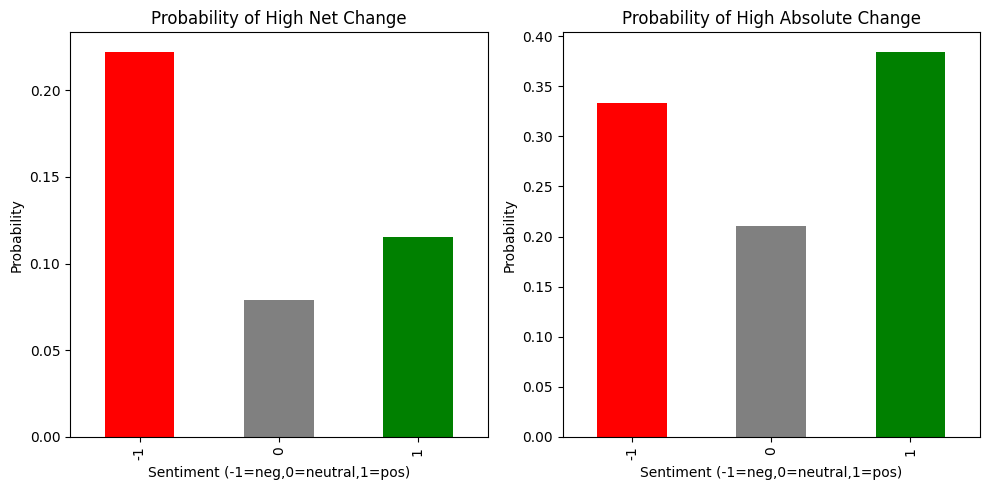

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("wiki_word_summary_aggregate.csv")

# import lexicon
def load_sentiment_lexicon(pos_file, neg_file):
    lexicon = {}
    # Positive words → +1
    with open(pos_file, encoding="utf-8") as f:
        for line in f:
            lexicon[line.strip()] = 1
    # Negative words → -1
    with open(neg_file, encoding="utf-8") as f:
        for line in f:
            lexicon[line.strip()] = -1
    return lexicon
polarity_lexicon = load_sentiment_lexicon("positive.txt", "negative.txt")

def get_word_sentiment(word, lexicon):
    if not isinstance(word, str):
        return 0  # treat as neutral
    return lexicon.get(word.lower(), 0)

df["sentiment"] = df["word"].apply(lambda w: get_word_sentiment(w, polarity_lexicon))

# net_change and absolute_change
median_net = df["net_change"].median()
median_abs = (df["times_added"] + df["times_removed"]).median()

df["net_high"] = df["net_change"] > median_net
df["abs_high"] = (df["times_added"] + df["times_removed"]) > median_abs

# finding probability per sentiment, sorting by -1, 0, 1
summary = df.groupby("sentiment")[["net_high", "abs_high"]].mean()
summary = summary.sort_index()  # optional: sort by -1,0,1
print("Probability of high net/absolute change by sentiment:\n")
print(summary)

# plotting
fig, ax = plt.subplots(1, 2, figsize=(10,5))

summary["net_high"].plot(kind="bar", ax=ax[0], color=["red","gray","green"])
ax[0].set_title("Probability of High Net Change")
ax[0].set_xlabel("Sentiment (-1=neg,0=neutral,1=pos)")
ax[0].set_ylabel("Probability")

summary["abs_high"].plot(kind="bar", ax=ax[1], color=["red","gray","green"])
ax[1].set_title("Probability of High Absolute Change")
ax[1].set_xlabel("Sentiment (-1=neg,0=neutral,1=pos)")
ax[1].set_ylabel("Probability")

plt.tight_layout()
plt.show()

Political Probaility (wip)

from transformers import pipeline
import numpy as np

classifier = pipeline(
    "text-classification",
    model="matous-volf/political-leaning-politics",
    tokenizer="matous-volf/political-leaning-politics",
    return_all_scores=True
)


MIN_EDIT_WORDS = 5

added_edits = []
removed_edits = []

for doc in ind_edits_dist:
    words = doc.split()

    added_words = [w[4:] for w in words if w.startswith("ADD_")]
    removed_words = [w[4:] for w in words if w.startswith("REM_")]

    if len(added_words) >= MIN_EDIT_WORDS:
        added_edits.append(" ".join(added_words))

    if len(removed_words) >= MIN_EDIT_WORDS:
        removed_edits.append(" ".join(removed_words))

print(f"Total added edits: {len(added_edits)}")
print(f"Total removed edits: {len(removed_edits)}")

LABEL_MAP = {
    "label_0": "left",
    "label_1": "center",
    "label_2": "right"
}

def classify_edits_probability(edits_list, batch_size=16):
    probs = {"left": [], "center": [], "right": []}

    for i in range(0, len(edits_list), batch_size):
        batch = edits_list[i:i + batch_size]
        outputs = classifier(batch)

        for out in outputs:
            # Case 1: return_all_scores=True
            if isinstance(out, list):
                for p in out:
                    mapped = LABEL_MAP[p["label"].lower()]
                    probs[mapped].append(p["score"])

            # Case 2: default pipeline output
            elif isinstance(out, dict):
                mapped = LABEL_MAP[out["label"].lower()]
                probs[mapped].append(out["score"])

    return {
        k: float(np.mean(v)) if len(v) > 0 else 0.0
        for k, v in probs.items()
    }

added_probs = classify_edits_probability(added_edits)
removed_probs = classify_edits_probability(removed_edits)

print("Average political probabilities in ADDED edits:", added_probs)
print("Average political probabilities in REMOVED edits:", removed_probs)


from transformers import pipeline
import numpy as np

classifier = pipeline(
    "text-classification",
    model="matous-volf/political-leaning-politics",
    tokenizer="matous-volf/political-leaning-politics",
    return_all_scores=True
)


MIN_EDIT_WORDS = 5

# ----------------------------
# Separate ADD / REM edits
# ----------------------------
added_edits = []
removed_edits = []

for doc in ind_edits_dist:
    words = doc.split()

    added_words = [w[4:] for w in words if w.startswith("ADD_")]
    removed_words = [w[4:] for w in words if w.startswith("REM_")]

    if len(added_words) >= MIN_EDIT_WORDS:
        added_edits.append(" ".join(added_words))

    if len(removed_words) >= MIN_EDIT_WORDS:
        removed_edits.append(" ".join(removed_words))

print(f"Total added edits: {len(added_edits)}")
print(f"Total removed edits: {len(removed_edits)}")

LABEL_MAP = {
    "label_0": "left",
    "label_1": "center",
    "label_2": "right"
}

def classify_edits_probability(edits_list, batch_size=16):
    probs = {"left": [], "center": [], "right": []}

    for i in range(0, len(edits_list), batch_size):
        batch = edits_list[i:i + batch_size]
        outputs = classifier(batch)

        for out in outputs:
            # Case 1: return_all_scores=True
            if isinstance(out, list):
                for p in out:
                    mapped = LABEL_MAP[p["label"].lower()]
                    probs[mapped].append(p["score"])

            # Case 2: default pipeline output
            elif isinstance(out, dict):
                mapped = LABEL_MAP[out["label"].lower()]
                probs[mapped].append(out["score"])

    return {
        k: float(np.mean(v)) if len(v) > 0 else 0.0
        for k, v in probs.items()
    }

# ----------------------------
# Run
# ----------------------------
added_probs = classify_edits_probability(added_edits)
removed_probs = classify_edits_probability(removed_edits)

print("Average political probabilities in ADDED edits:", added_probs)
print("Average political probabilities in REMOVED edits:", removed_probs)

Finally, Survival

In [ ]:
import pandas as pd

# Load the aggregate word csv
df = pd.read_csv("wiki_word_summary_aggregate.csv")

# Compute survival fraction
# Avoid division by zero if times_added is 0
df["survival_fraction"] = df.apply(
    lambda row: row["net_change"] / row["times_added"] if row["times_added"] > 0 else 0,
    axis=1
)

# Sort by survival fraction descending (highest survival first)
df_sorted = df.sort_values(by="survival_fraction", ascending=False)

# Optionally, inspect top surviving words
print(df_sorted[["word", "times_added", "times_removed", "net_change", "survival_fraction"]].head(20))

# Save results
df_sorted.to_csv("wiki_word_survival.csv", index=False)
print("Saved word-level survival to wiki_word_survival.csv")

           word  times_added  times_removed  net_change  survival_fraction
256      boston            1              0           1                1.0
31      content            2              0           2                1.0
29           10            2              0           2                1.0
28      mixture            2              0           2                1.0
26       hebert            2              0           2                1.0
24        baked            2              0           2                1.0
22        cakes            2              0           2                1.0
19      candies            2              0           2                1.0
18       liquor            2              0           2                1.0
16         drug            2              0           2                1.0
255      stored            1              0           1                1.0
254    benefits            1              0           1                1.0
253          dl          